## Diffusion model 03: AEMET Dataset

Author: diego.camarero@estudiante.uam.es

In [ ]:
!pip install -q scikit-fda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.7/287.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.3 MB/s eta 0:00:00


In [ ]:
experiment_number = '03'

kernel_sizes = (21, 17, 9, 9)

lambda_min = 0.0005
lambda_max = 7.5

dataset_size = 73
n_points = 365

training_epochs = 10000

experiment_name = f"training_diffusion_{experiment_number}_AEMET"

In [ ]:
from google.colab import drive
import os
import sys
import torch

drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 5/Scalar diffusion/notebooks'
%cd "{PROJECT_PATH}"


BASE_DIR = os.path.abspath("..")
CHECKPOINTS_DIR = os.path.join(BASE_DIR, "checkpoints")

if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n[INFO] Running on device: {device}\n")

Mounted at /content/drive
/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 5/Scalar diffusion/notebooks

[INFO] Running on device: cuda



In [ ]:
from utils.reproducibility import seed_everything, seed_worker

seed = 42
seed_everything(seed)

In [ ]:
# Jupyter
# %load_ext autoreload
# %autoreload 2

# Standard library
from functools import partial

# Third-party
import numpy as np

# PyTorch
import torch
from torch.utils.data import DataLoader
from torch.optim import Adam

# Project modules
import diffusion.diffusion_process as dfp

from models.score_model import UNetScoreModel

from skfda.datasets import fetch_aemet

from utils.metrics import (
    plot_training_evolution,
    plot_loss_history,
)

from utils.checkpoints import (
    save_checkpoint,
    load_checkpoint,
)

from utils.training_plots import (
    plot_function_grid,
    plot_ou_diffusion_process,
    plot_distribution_convergence,
)

## Dataset creation

In [ ]:
print("Loading dataset...")

X, _ = fetch_aemet(return_X_y=True)
data_train = torch.tensor(X.data_matrix, dtype=torch.float32)[..., 0] # 0 for daily temperature, 1 for daily precipitation, 2 for daily wind speed
data_train = data_train.unsqueeze(1)
print(f"Dataset shape: {data_train.shape}")

# Normalize dataset
data_mean = data_train.mean()
data_std = data_train.std()
data_eps = 1e-8
data_train_norm = (data_train - data_mean) / (data_std + data_eps)

Loading dataset...
Dataset shape: torch.Size([73, 1, 365])


torch.Size([8, 1, 365])


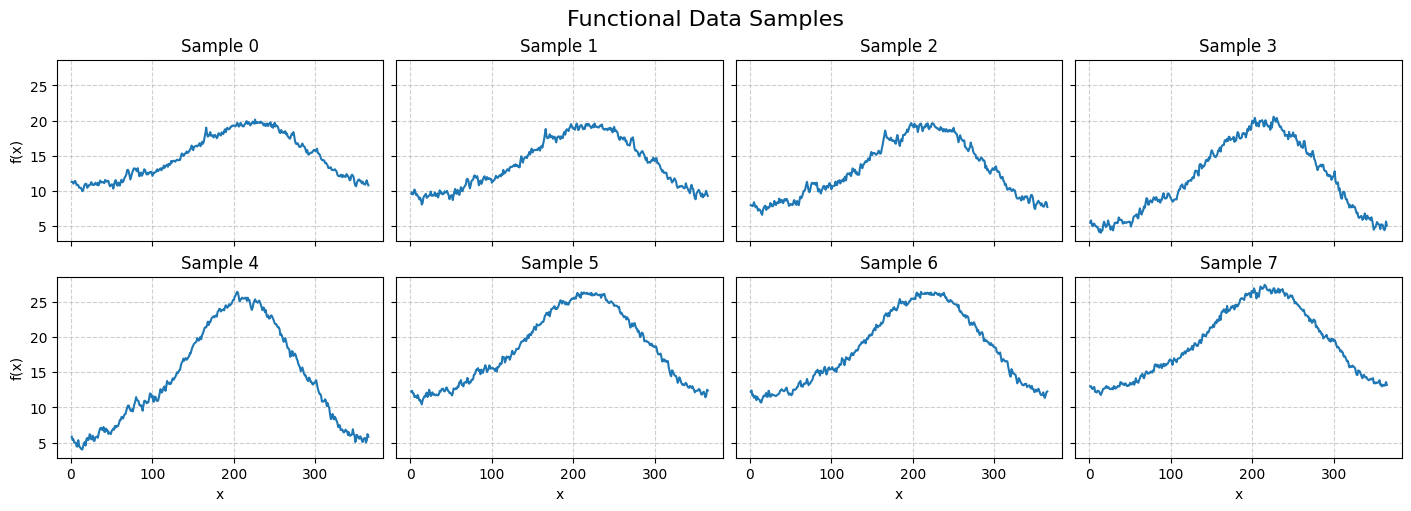

In [ ]:
# Create functional dataset

N, _, M = data_train.shape
x_inf, x_sup = 1.0, 365.0
axis_x = torch.linspace(x_inf, x_sup, M)

# Plot some examples of the dataset

n_examples = 8
examples = torch.stack([data_train[i] for i in range(n_examples)])
print(examples.shape)

plot_function_grid(
    examples,
    n_plots=n_examples,
    axis_x=axis_x,
)

## Diffusion process

In [ ]:
t_0 = 0.0
T = 1.0
t_eps = 1.0e-3

lambda_t = lambda t: lambda_min + (t-t_0) / (T-t_0) * (lambda_max - lambda_min)

def drift_coefficient(x_t, t):
    t = t.view(-1, 1, 1)
    return - lambda_t(t) * x_t

def diffusion_coefficient(t):
    t = t.view(-1, 1, 1)
    return torch.sqrt(2 * lambda_t(t))

def mu_t(x_0, t):
    return x_0 * torch.exp(-lambda_min*(t-t_0) - (t-t_0)**2 / (2*(T-t_0)) * (lambda_max - lambda_min))

def sigma_t(t):
    return torch.sqrt(1 - torch.exp(-2 * lambda_min * (t-t_0) - (t-t_0)**2 /(T-t_0) * (lambda_max - lambda_min)))

def inverse_mu_t(t):
    return torch.exp(lambda_min*(t-t_0) + (t-t_0)**2 / (2*(T-t_0)) * (lambda_max - lambda_min))

diffusion_process = dfp.GaussianDiffusionProcess(
    drift_coefficient,
    diffusion_coefficient,
    mu_t,
    sigma_t,
    t_0=t_0,
    t_end=T,
    t_eps=t_eps,
)

torch.Size([73, 100, 1, 365])


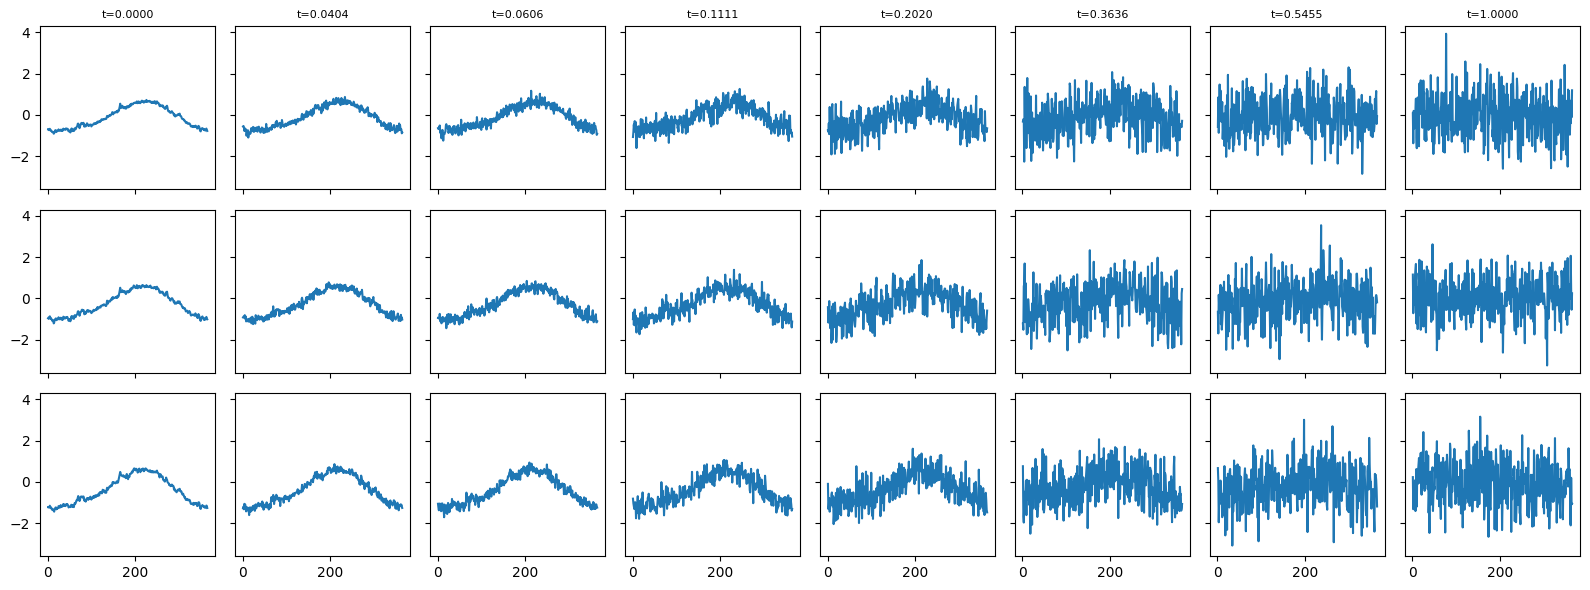

In [ ]:
torch.manual_seed(seed)
n_steps = 100
times, X = dfp.euler_maruyama_integrator(
    x_initial=data_train_norm[:].to(device),
    t_start=t_0,
    t_end=T,
    n_times=n_steps,
    drift_coefficient=drift_coefficient,
    diffusion_coefficient=diffusion_coefficient,
)
print(X.shape)

plot_ou_diffusion_process(
    X,
    axis_x,
    num_steps=8,
    t_start=t_0,
    t_end=T,
)

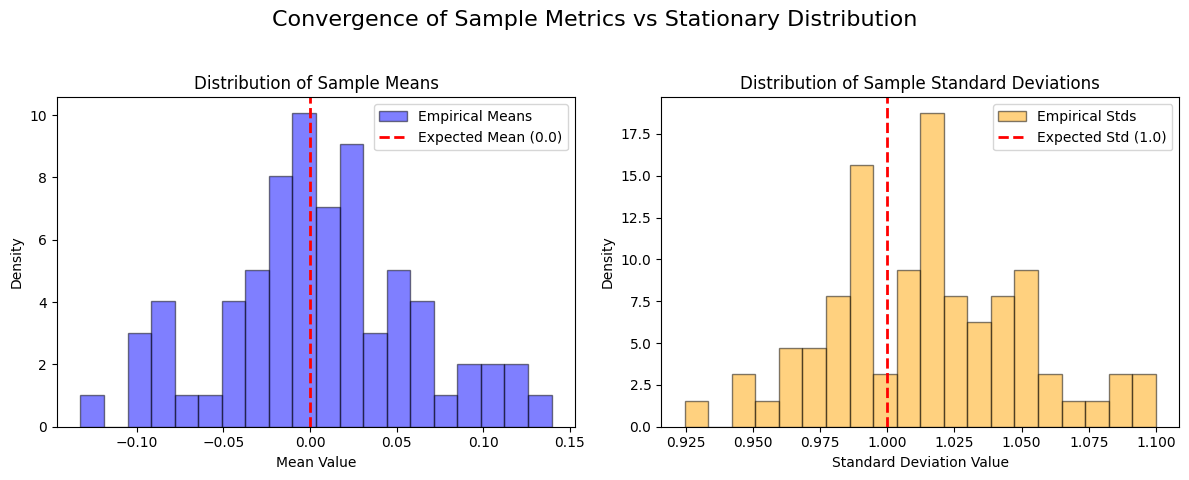

In [ ]:
plot_distribution_convergence(
    X,
    loc_stationary=0.0,
    scale_stationary=1.0,
)

## Training

In [ ]:
# Define the score model

def multiply_inv_sigma(h,t):
    h = h / sigma_t(t)[:, None]
    return h

score_model = UNetScoreModel(
    multiply_inv_sigma=multiply_inv_sigma,
    kernel_sizes=kernel_sizes,
    random_state=seed,
    device=device,
)

learning_rate = 1.0e-3
optimizer = Adam(score_model.parameters(), lr=learning_rate)
n_epochs = training_epochs
save_every = max(1, n_epochs // 10)

  0%|          | 0/10000 [00:00<?, ?it/s]

Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 5/Scalar diffusion/checkpoints/training_diffusion_03_AEMET/checkpoint_epoch_1.pth
Epoch: 1. Loss: 3938.898511. Time: 00:01
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 5/Scalar diffusion/checkpoints/training_diffusion_03_AEMET/checkpoint_epoch_1000.pth
Epoch: 1000. Loss: 13.062050. Time: 02:58
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 5/Scalar diffusion/checkpoints/training_diffusion_03_AEMET/checkpoint_epoch_2000.pth
Epoch: 2000. Loss: 13.655258. Time: 05:56
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 5/Scalar diffusion/checkpoints/training_diffusion_03_AEMET/checkpoint_epoch_3000.pth
Epoch: 3000. Loss: 9.614655. Time: 08:54
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 5/Scalar diffusion/checkpoints/training_diffusion_03_AEMET/checkpoint_epoch_4000.pth
Ep

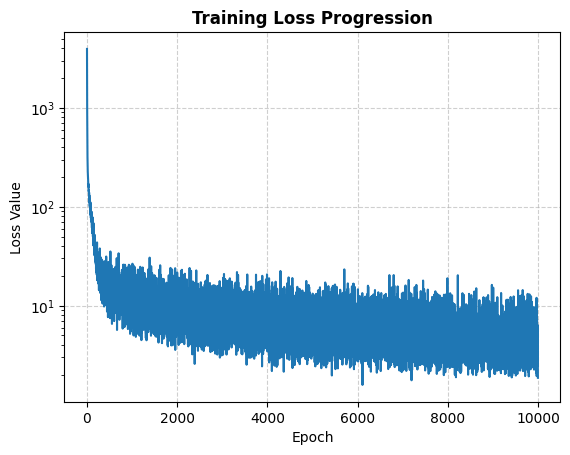

In [ ]:
# Train model
import time
import torchvision.transforms as transforms
import tqdm
from tqdm.notebook import tqdm, trange

batch_size = 32

data_loader = DataLoader(
    data_train_norm,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    worker_init_fn=seed_worker,
)

tqdm_epoch = trange(n_epochs)

loss_history = {
    "epoch": [],
    "loss": []
}

start_time = time.time()
for epoch in tqdm_epoch:
    avg_loss = 0.0
    num_items = 0
    for x in data_loader:
        x = x.to(device)
        loss = diffusion_process.loss_function(score_model, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    epoch_loss = avg_loss / num_items
    elapsed_time = time.time() - start_time
    tqdm_epoch.set_description('Average Loss: {:5f}'.format(epoch_loss))

    loss_history["epoch"].append(epoch + 1)
    loss_history["loss"].append(epoch_loss)

    if epoch == 0 or (epoch + 1) % save_every == 0:
        save_checkpoint(
            epoch=epoch,
            model=score_model,
            optimizer=optimizer,
            loss=epoch_loss,
            elapsed_time=elapsed_time,
            experiment_name=experiment_name,
            checkpoints_dir=CHECKPOINTS_DIR,
        )

if n_epochs % save_every != 0:
    save_checkpoint(
        epoch=n_epochs - 1,
        model=score_model,
        optimizer=optimizer,
        loss=epoch_loss,
        elapsed_time=elapsed_time,
        experiment_name=experiment_name,
        checkpoints_dir=CHECKPOINTS_DIR,
    )

plot_loss_history(loss_history)

## Synthetic data generation

In [ ]:
# Compute results

saved_epochs = [n_epochs]

checkpoint_paths = [
    os.path.join(
        CHECKPOINTS_DIR,
        experiment_name,
        f"checkpoint_epoch_{epoch}.pth"
    )
    for epoch in saved_epochs
]

def backward_drift_coefficient(x_t, t, drift_coefficient, diffusion_coefficient, score_model):
    score = score_model(x_t, t)
    return drift_coefficient(x_t, t) - diffusion_coefficient(t).view(-1, 1, 1) ** 2 * score

n_functions = 73
torch.manual_seed(seed)
noise_T = torch.randn(n_functions, 1, M, device=device)

for ckpt_path in checkpoint_paths:

    score_model, optimizer, epoch, loss, elapsed_time = load_checkpoint(ckpt_path, score_model, optimizer)
    score_model.eval()

    torch.manual_seed(seed)

    with torch.no_grad():
        times, synthetic_functions_t = dfp.euler_maruyama_integrator(
                x_initial=noise_T,
                t_start=T,
                t_end=t_0 + t_eps,
                n_times=n_steps,
                drift_coefficient=partial(
                    backward_drift_coefficient,
                    drift_coefficient=drift_coefficient,
                    diffusion_coefficient=diffusion_coefficient,
                    score_model=score_model,
                ),
                diffusion_coefficient=diffusion_coefficient,
            )

        synthetic_functions_norm = dfp.inverse_Tweedie_formula(
            x_t=synthetic_functions_t[:, -1, :, :],
            t=t_eps,
            inv_mu_t=inverse_mu_t,
            sigma_t=sigma_t,
            score_model=score_model,
        )

        synthetic_functions_t = torch.cat(
            [synthetic_functions_t, synthetic_functions_norm.unsqueeze(1)],
            dim=1,
            )

        synthetic_functions = (synthetic_functions_norm * (data_std + data_eps) + data_mean)

Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 5/Scalar diffusion/checkpoints/training_diffusion_03_AEMET/checkpoint_epoch_10000.pth
Epoch: 10000. Loss: 1.866337. Time: 29:46


## Results

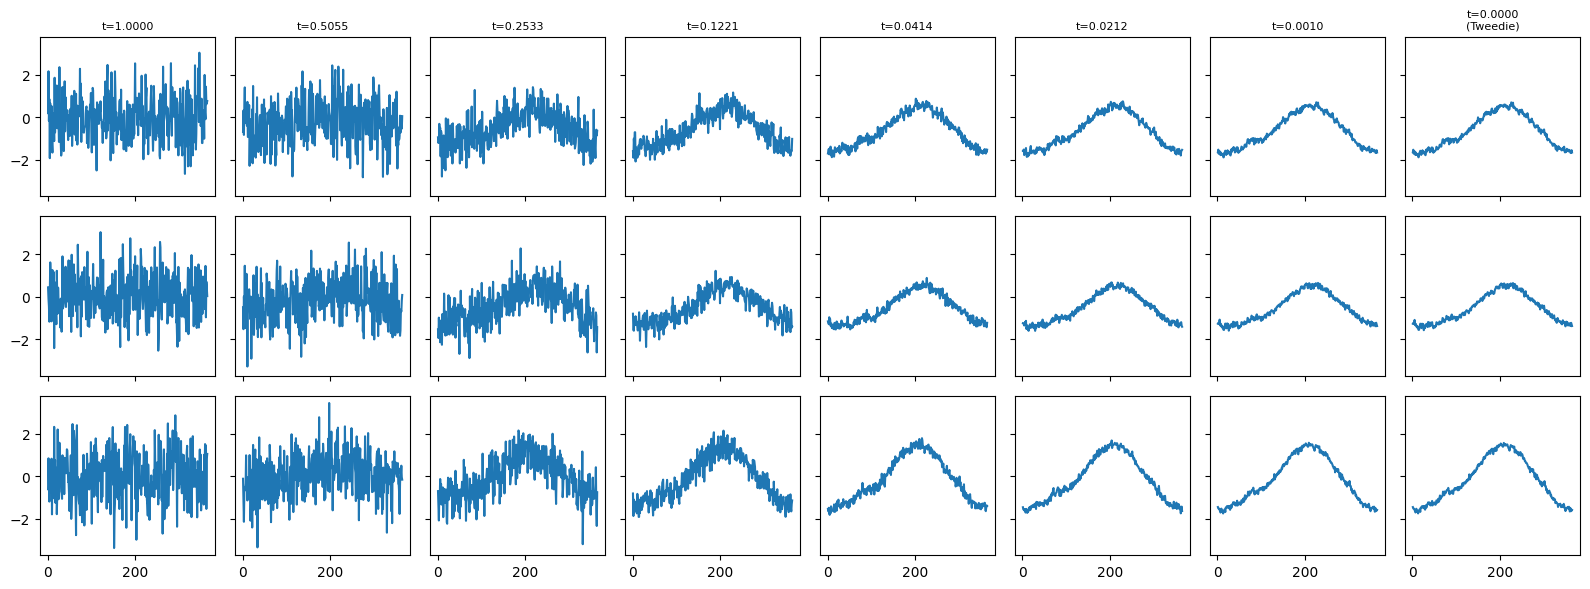

In [ ]:
plot_ou_diffusion_process(
    synthetic_functions_t,
    axis_x,
    num_steps=8,
    t_start=T,
    t_end=t_eps,
    tweedie_final=True,
)

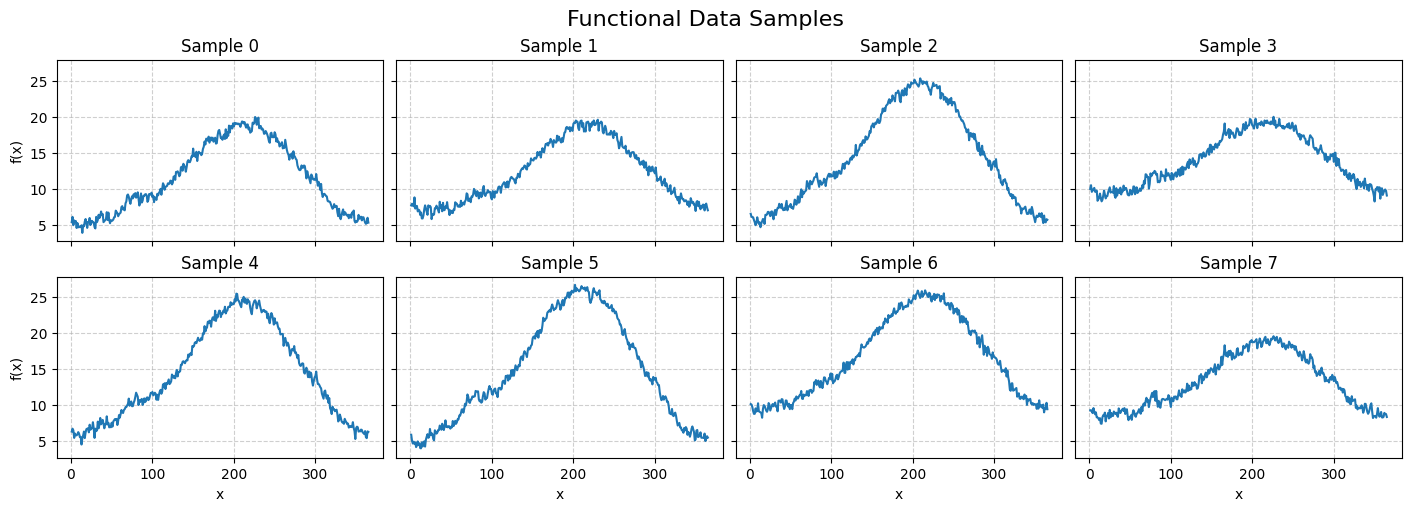

In [ ]:
plot_function_grid(
    synthetic_functions,
    n_plots=8,
    axis_x=axis_x,
)

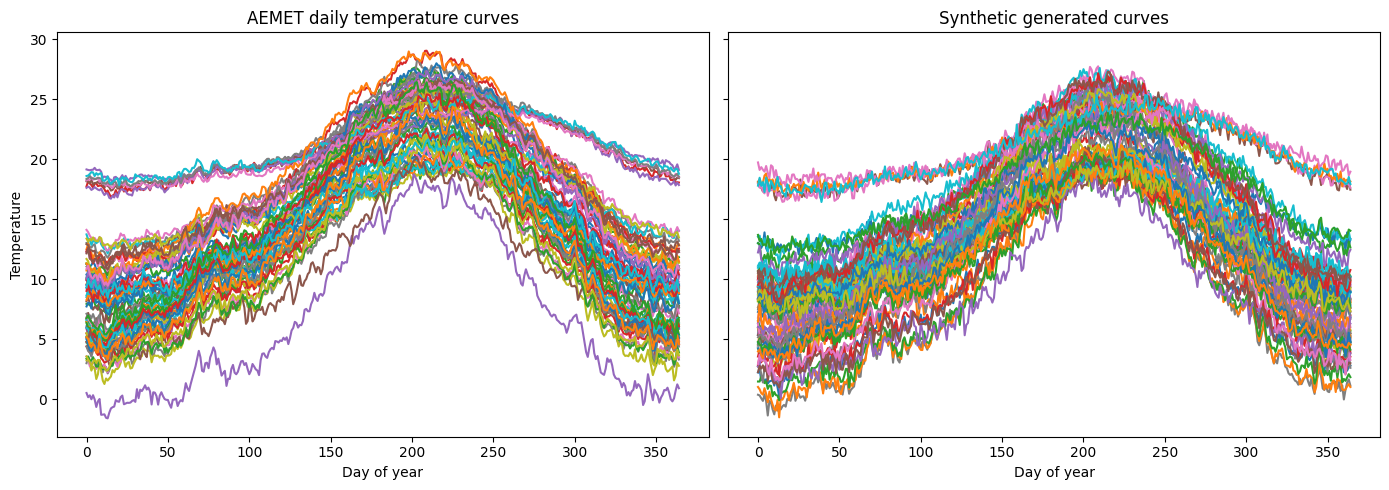

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i in range(data_train.shape[0]):
    axes[0].plot(data_train[i, 0, :].numpy())
axes[0].set_xlabel("Day of year")
axes[0].set_ylabel("Temperature")
axes[0].set_title("AEMET daily temperature curves")

for i in range(synthetic_functions.shape[0]):
    axes[1].plot(synthetic_functions[i, 0, :].cpu().numpy())
axes[1].set_xlabel("Day of year")
axes[1].set_title("Synthetic generated curves")

plt.tight_layout()
plt.show()